# 02 — EDA: Question volume

**Goal:** First look at monthly question volume per tag. Establishes whether the headline story (LLM-friendly tags declined after ChatGPT, LLM-unfriendly didn't) is visible in the raw data.

**Outputs:**
1. Sanity check: row counts, missing months per tag.
2. Spaghetti plot of all 14 tags over time.
3. Group-mean time series, raw and normalized.
4. Heatmap of activity per tag-month.
5. Pre/post percent change per tag (the headline number).

## Colab setup (skip if running locally)

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())
if IN_COLAB:
    # Clone repo and cd into it. Replace URL after pushing to GitHub.
    REPO_URL = 'https://github.com/<YOUR_ORG>/math189-stackoverflow-llm.git'
    if not os.path.exists('math189-stackoverflow-llm'):
        !git clone {REPO_URL}
    %cd math189-stackoverflow-llm
    !pip install -q -r requirements.txt
    # Raw CSVs live on Google Drive — mount and copy in.
    from google.colab import drive
    drive.mount('/content/drive')
    !cp /content/drive/MyDrive/math189-data/raw/*.csv data/raw/ 2>/dev/null || echo 'No raw CSVs yet — pull from SEDE first.'

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load import (
    load_monthly_panel, panel_summary,
    LLM_FRIENDLY, LLM_UNFRIENDLY, TREATMENT_DATE
)
from src.plots import (
    setup_style, add_chatgpt_line,
    plot_volume_by_tag, plot_group_mean, GROUP_COLORS,
)

setup_style()
print(f'Treatment date: {TREATMENT_DATE.date()}')
print(f'LLM-friendly tags ({len(LLM_FRIENDLY)}): {LLM_FRIENDLY}')
print(f'LLM-unfriendly tags ({len(LLM_UNFRIENDLY)}): {LLM_UNFRIENDLY}')

Treatment date: 2022-12-01
LLM-friendly tags (7): ['python', 'javascript', 'reactjs', 'pandas', 'html', 'css', 'sql']
LLM-unfriendly tags (7): ['assembly', 'verilog', 'vhdl', 'cobol', 'fortran', 'embedded', 'kernel']


## 1. Load and sanity-check the panel

In [2]:
panel = load_monthly_panel('../data/raw')
print('Panel shape:', panel.shape)
panel.head()

Panel shape: (1007, 11)


,month,tag,group,llm_friendly,post_chatgpt,n_questions,avg_body_len,avg_score,accept_rate,answered_rate,unique_askers
0,2019-01-01,assembly,llm_unfriendly,0,0,219,1595.136986,1.904110,0.452054,0.753424,183
1,2019-02-01,assembly,llm_unfriendly,0,0,223,1573.013453,1.565022,0.497757,0.775784,180
2,2019-03-01,assembly,llm_unfriendly,0,0,276,1551.913043,1.231884,0.413043,0.681159,219
3,2019-04-01,assembly,llm_unfriendly,0,0,303,1623.636964,0.986799,0.396039,0.729372,248
4,2019-05-01,assembly,llm_unfriendly,0,0,234,1673.491453,1.700855,0.517094,0.799145,198


In [3]:
# Each tag should have ~72 monthly rows (Jan 2019 - Dec 2024).
# Anything materially less is a red flag — gaps in SEDE results or a quiet tag.
summary = panel_summary(panel)
summary

,tag,n_months,first_month,last_month,total_questions
0,assembly,72,2019-01-01,2024-12-01,15502
1,cobol,72,2019-01-01,2024-12-01,602
2,css,72,2019-01-01,2024-12-01,224603
3,embedded,72,2019-01-01,2024-12-01,4110
4,fortran,72,2019-01-01,2024-12-01,4024
5,html,72,2019-01-01,2024-12-01,322941
6,javascript,72,2019-01-01,2024-12-01,830026
7,kernel,72,2019-01-01,2024-12-01,2415
8,pandas,72,2019-01-01,2024-12-01,199742
9,python,72,2019-01-01,2024-12-01,1144097


In [4]:
# Look for missing months per tag
all_months = pd.date_range('2019-01-01', '2024-12-01', freq='MS')
missing = []
for tag, g in panel.groupby('tag'):
    miss = set(all_months) - set(g['month'])
    if miss:
        missing.append((tag, sorted(miss)))
if missing:
    for tag, months in missing:
        print(f'{tag}: {len(months)} missing months — first few: {[m.strftime("%Y-%m") for m in months[:5]]}')
else:
    print('No missing months across any tag.')

vhdl: 1 missing months — first few: ['2024-12']


## 2. Volume over time — all 14 tags

First look at the data. Red lines are LLM-friendly tags, blue are LLM-unfriendly. The vertical dashed line is the ChatGPT release.

FileNotFoundError: [Errno 2] No such file or directory: '/Users/srikarmannam/Documents/math189-stackoverflow-llm/notebooks/reports/figures/02_volume_spaghetti.png'

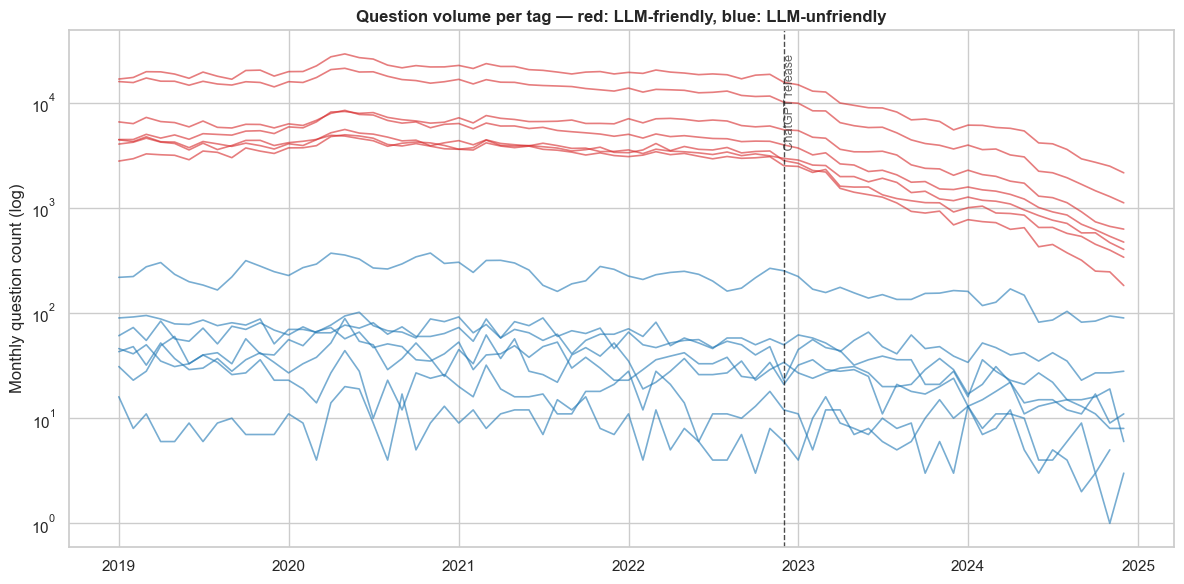

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_volume_by_tag(panel, log_y=True, ax=ax)
plt.tight_layout()
plt.savefig('reports/figures/02_volume_spaghetti.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Group means — raw and normalized

Normalized version divides each group by its pre-ChatGPT mean so both start at 1. This is the cleanest visual of the differential trend.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_group_mean(panel, 'n_questions', ax=axes[0], normalize=False)
axes[0].set_title('Mean monthly questions per tag, by group (raw)')
plot_group_mean(panel, 'n_questions', ax=axes[1], normalize=True)
axes[1].set_title('Mean monthly questions, normalized to pre-ChatGPT mean = 1')
plt.tight_layout()
plt.savefig('reports/figures/02_group_mean_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Heatmap of normalized activity per tag-month

Rows = tags, columns = months. Each cell shows volume relative to the tag's own pre-ChatGPT mean. Red columns after Dec 2022 = volume *dropped*; this should be much more visible in the LLM-friendly block than the LLM-unfriendly block.

In [ ]:
pre_means = panel[panel['post_chatgpt'] == 0].groupby('tag')['n_questions'].mean()
panel['n_questions_rel'] = panel.apply(lambda r: r['n_questions'] / pre_means[r['tag']], axis=1)

tag_order = LLM_FRIENDLY + LLM_UNFRIENDLY  # group treatment rows together
heat = panel.pivot(index='tag', columns='month', values='n_questions_rel').loc[tag_order]
heat.columns = [m.strftime('%Y-%m') for m in heat.columns]

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(heat, cmap='RdBu_r', center=1.0, vmin=0, vmax=2,
            cbar_kws={'label': 'Volume relative to pre-ChatGPT mean'}, ax=ax)
# Mark the boundary between treatment and control
ax.axhline(len(LLM_FRIENDLY), color='black', linewidth=2)
# Mark the treatment date
treatment_col = list(heat.columns).index('2022-12')
ax.axvline(treatment_col, color='black', linewidth=2, linestyle='--')
ax.set_title('Relative question volume per tag-month (1.0 = each tag\'s pre-ChatGPT mean)')
ax.set_xlabel('')
ax.set_ylabel('')
# Thin out x-tick labels
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 6 == 0)
plt.tight_layout()
plt.savefig('reports/figures/02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Pre/post percent change per tag — the headline number

For each tag, compute mean volume in the pre period (2019-01 to 2022-11) vs post (2022-12 to 2024-12), and the percent change. If our hypothesis is right, LLM-friendly tags show 30–50%+ drops; LLM-unfriendly tags show <10% drops (or flat).

In [ ]:
pre_post = (
    panel.groupby(['tag', 'group', 'post_chatgpt'])['n_questions'].mean()
    .unstack('post_chatgpt')
    .rename(columns={0: 'pre_mean', 1: 'post_mean'})
)
pre_post['pct_change'] = (pre_post['post_mean'] - pre_post['pre_mean']) / pre_post['pre_mean'] * 100
pre_post = pre_post.reset_index().sort_values(['group', 'pct_change'])
pre_post.round(1)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = pre_post['group'].map(GROUP_COLORS)
ax.barh(pre_post['tag'], pre_post['pct_change'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% change in mean monthly question volume\n(post-ChatGPT vs pre-ChatGPT)')
ax.set_title('Volume change by tag — red = LLM-friendly, blue = LLM-unfriendly')
plt.tight_layout()
plt.savefig('reports/figures/02_pct_change_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save the cleaned panel for downstream notebooks

In [ ]:
panel.to_csv('data/interim/monthly_panel.csv', index=False)
print('Saved data/interim/monthly_panel.csv -', panel.shape)

## Notes / TODO

- [ ] Pre-trend check (parallel trends in 2019–2022) — see notebook 04.
- [ ] Decompose seasonality before claiming the post-ChatGPT drop is real (some tags are seasonal).
- [ ] Sanity-check Python and JavaScript volumes against Stack Exchange's published trends page to make sure our pulls are correct.